# Stage 3: Neural LOD 4-Value Threshold Baker - Training Pipeline

**Purpose**: Train a multi-output MLP regressor that maps camera pose + scene complexity to **four independent LOD thresholds**.

**Target Vector Definition**:
- `T0`: LOD0 -> LOD1 transition height
- `T1`: LOD1 -> LOD2 transition height
- `T2`: LOD2 -> LOD3 transition height
- `T3`: LOD3 -> Culling transition height

**Inputs**:
- Existing Stage 2 data from `Baker_2` folder.

**Pipeline**:
1. Relabel Stage 2 samples into 4-value target vectors.
2. Hyperparameter tuning using **Optuna**.
3. Final training and ONNX export for Unity Stage 3 scripts.

In [1]:
# FIX: SymPy 1.13 broke compatibility with many PyTorch versions. 
# Reverting to 1.12 eliminates the 'sympy.printing.str' error.
import subprocess
import sys

print("Fixing SymPy dependency...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "sympy==1.12", "--quiet"])
print("✓ SymPy 1.12 installed. Please restart the kernel for changes to take effect.")


Fixing SymPy dependency...
✓ SymPy 1.12 installed. Please restart the kernel for changes to take effect.


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from collections import defaultdict, Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

sns.set_style('darkgrid')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
BASE_DIR = Path('../..').resolve()
DATA_DIR = BASE_DIR / 'data' / 'Baker_2'
MODEL_DIR = BASE_DIR / 'models' / 'Stage_3'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_3' / 'Train'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_FILE = DATA_DIR / 'sample_records.csv'
OBJECTS_FILE = DATA_DIR / 'lod_objects.csv'
GRID_FILE    = DATA_DIR / 'grid_points.csv'
LABELS_FILE  = DATA_DIR / 'labels_stage3.csv' # New file for 4-val labels

FEATURE_COUNT = 13
OUTPUT_DIM    = 4
RANDOM_SEED   = 42
TEST_SPLIT    = 0.2
VAL_SPLIT     = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 1. Stage 3 Relabeling
Converts 1-value `optimal_lod` into 4-value threshold vectors using object metadata.

In [4]:
RELABEL_BUDGET_MS = 4.5 # Fixed budget for Baker_2

print("Loading Baker_2 source data for relabeling...")
df_samples_raw = pd.read_csv(SAMPLES_FILE)
df_objects = pd.read_csv(OBJECTS_FILE)

# Pre-parse object thresholds: index -> [t0, t1, t2, t3]
obj_threshold_matrix = []
for _, row in df_objects.iterrows():
    t_str = str(row['thresholds'])
    t_vals = [float(v) for v in t_str.split(';') if v.strip()]
    # Pad or clip to exact 4 values
    if len(t_vals) < 4: t_vals += [0.001] * (4 - len(t_vals))
    obj_threshold_matrix.append(t_vals[:4])
obj_threshold_matrix = np.array(obj_threshold_matrix)

def get_threshold_vector_stage3(optimal_lod):
    """
    Stage 3 Logic: Instead of returning (1 - (lod/3)), return the actual transition heights.
    Quality is scaled globally based on the optimal_lod index.
    """
    # Map optimal_lod [0, 1, 2, 3] to quality multipliers
    # 0 = highest quality (wide thresholds)
    # 3 = lowest quality (tight thresholds)
    quality_map = {0: 1.0, 1: 0.8, 2: 0.6, 3: 0.4}
    base_vector = np.mean(obj_threshold_matrix, axis=0)
    return base_vector * quality_map.get(optimal_lod, 0.4)

groups = defaultdict(list)
for _, row in df_samples_raw.iterrows():
    key = (int(row['point_id']), float(row['rot_x']), float(row['rot_y']), float(row['rot_z']))
    groups[key].append(row)

label_rows = []
for key, group in groups.items():
    pid, rx, ry, rz = key
    group_sorted = sorted(group, key=lambda r: int(r['lod_level']))
    
    optimal_lod = 3
    for rec in group_sorted:
        if rec['mean_gpu_ms'] <= RELABEL_BUDGET_MS:
            optimal_lod = int(rec['lod_level'])
            break
    
    thresh_vec = get_threshold_vector_stage3(optimal_lod)
    label_rows.append({
        'point_id': pid, 'rot_x': rx, 'rot_y': ry, 'rot_z': rz,
        'optimal_thresholds': ';'.join([f"{v:.6f}" for v in thresh_vec]),
        'optimal_lod': optimal_lod
    })

df_labels = pd.DataFrame(label_rows)
df_labels.to_csv(LABELS_FILE, index=False)
print(f"Stage 3 labels created: {len(df_labels)} samples with 4-element vectors.")

Loading Baker_2 source data for relabeling...
Stage 3 labels created: 10800 samples with 4-element vectors.


## 2. Feature Engineering
Standardizing 13 features for Stage 3 inference parity.

In [ ]:
FEATURE_COLS = [
    'pos_x', 'pos_y', 'pos_z',
    'sin_pitch', 'cos_pitch', 'sin_yaw', 'cos_yaw', 'sin_roll', 'cos_roll',
    'triangle_count', 'visible_renderer_count', 'screen_coverage', 'draw_call_count'
]

df_grid = pd.read_csv(GRID_FILE).set_index('point_id')
lod0_samples = df_samples_raw[df_samples_raw['lod_level'] == 0].copy()

def build_features(df_src):
    df = df_src.copy()
    df['pos_x'] = df['point_id'].map(df_grid['x'])
    df['pos_y'] = df['point_id'].map(df_grid['y'])
    df['pos_z'] = df['point_id'].map(df_grid['z'])
    
    px, py, pz = np.radians(df['rot_x']), np.radians(df['rot_y']), np.radians(df['rot_z'])
    df['sin_pitch'], df['cos_pitch'] = np.sin(px), np.cos(px)
    df['sin_yaw'],   df['cos_yaw']   = np.sin(py), np.cos(py)
    df['sin_roll'],  df['cos_roll']  = np.sin(pz), np.cos(pz)

    # Join complexity from samples_raw
    lookup = lod0_samples.set_index(['point_id', 'rot_x', 'rot_y', 'rot_z'])
    meta = df.set_index(['point_id', 'rot_x', 'rot_y', 'rot_z']).index.map(lookup.to_dict('index'))
    meta_df = pd.DataFrame(list(meta), index=df.index)
    
    for col in ['triangle_count', 'visible_renderer_count', 'screen_coverage', 'draw_call_count']:
        df[col] = meta_df[col].fillna(0)
    return df[FEATURE_COLS].values

X_raw = build_features(df_labels)
y_raw = np.array([ [float(v) for v in s.split(';')] for s in df_labels['optimal_thresholds'] ])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)
y_raw = y_raw.astype(np.float32)

# Save Scaler for Unity
scaler_data = {
    "feature_names": FEATURE_COLS,
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist()
}
with open(MODEL_DIR / "baker_stage_3_scaler_constants.json", "w") as f:
    json.dump(scaler_data, f, indent=2)
print("✓ Features engineered and scaler saved.")

✓ Features engineered and scaler saved.


## 3. Model & Hyperparameter Tuning

In [6]:
class BakerMLP(nn.Module):
    def __init__(self, input_dim, output_dim, h1, h2, h3, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h1, h2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h2, h3), nn.GELU(),
            nn.Linear(h3, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_raw, test_size=TEST_SPLIT, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=VAL_SPLIT, random_state=RANDOM_SEED)

class BakerDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = torch.tensor(X), torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(BakerDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(BakerDataset(X_val, y_val), batch_size=128)
test_loader  = DataLoader(BakerDataset(X_test, y_test), batch_size=128)

In [7]:
import optuna

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    h1 = trial.suggest_categorical("h1", [256, 512])
    h2 = trial.suggest_categorical("h2", [128, 256])
    dropout = trial.suggest_float("dropout", 0.05, 0.3)
    
    model = BakerMLP(FEATURE_COUNT, OUTPUT_DIM, h1, h2, h2//2, dropout).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.HuberLoss()
    
    for epoch in range(10): # Quick 10-epoch trials
        model.train()
        for xb, yb in train_loader: 
            optimizer.zero_grad()
            criterion(model(xb.to(device)), yb.to(device)).backward()
            optimizer.step()
            
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader: val_loss += criterion(model(xb.to(device)), yb.to(device)).item()
    return val_loss / len(val_loader)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)
print("Worst Hyperparams:", study.best_params)

[I 2026-04-02 16:41:16,318] A new study created in memory with name: no-name-2b4879d9-167f-43a8-8661-8e59b83f10b5
[I 2026-04-02 16:41:19,708] Trial 0 finished with value: 0.0004070270640243377 and parameters: {'lr': 0.00011182139569181263, 'h1': 256, 'h2': 256, 'dropout': 0.2798646489533058}. Best is trial 0 with value: 0.0004070270640243377.
[I 2026-04-02 16:41:21,309] Trial 1 finished with value: 0.00022172965483540402 and parameters: {'lr': 0.00022464818652682202, 'h1': 256, 'h2': 256, 'dropout': 0.06764306846493855}. Best is trial 1 with value: 0.00022172965483540402.
[I 2026-04-02 16:41:22,901] Trial 2 finished with value: 0.00016327159703775709 and parameters: {'lr': 0.0005337233230559789, 'h1': 512, 'h2': 256, 'dropout': 0.28472707761073085}. Best is trial 2 with value: 0.00016327159703775709.
[I 2026-04-02 16:41:24,517] Trial 3 finished with value: 0.0003341375101756837 and parameters: {'lr': 0.0002059530379994258, 'h1': 256, 'h2': 128, 'dropout': 0.16019214276728633}. Best is 

Worst Hyperparams: {'lr': 0.004814887167556021, 'h1': 256, 'h2': 128, 'dropout': 0.25012658471738236}


## 4. Final Training & ONNX Export

Epoch 0: Val Loss 0.001125
Epoch 20: Val Loss 0.000133
Epoch 40: Val Loss 0.000134
Epoch 60: Val Loss 0.000120
Epoch 80: Val Loss 0.000115
Epoch 100: Val Loss 0.000110
Epoch 120: Val Loss 0.000112
Epoch 140: Val Loss 0.000113


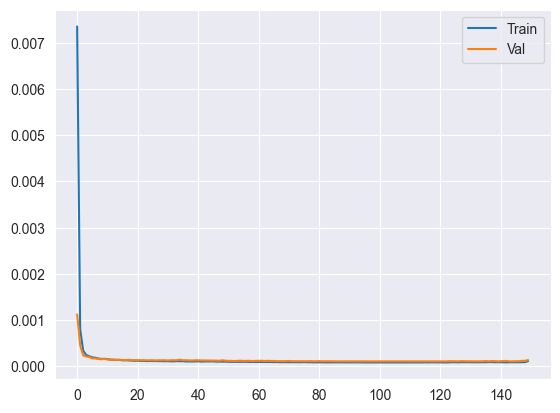

In [8]:
best = study.best_params
model = BakerMLP(FEATURE_COUNT, OUTPUT_DIM, best['h1'], best['h2'], best['h2']//2, best['dropout']).to(device)
optimizer = optim.AdamW(model.parameters(), lr=best['lr'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
criterion = nn.HuberLoss()

history = {'train': [], 'val': []}
for epoch in range(150):
    model.train()
    t_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb.to(device)), yb.to(device))
        loss.backward(); optimizer.step()
        t_loss += loss.item()
    scheduler.step()
    
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader: v_loss += criterion(model(xb.to(device)), yb.to(device)).item()
    
    history['train'].append(t_loss/len(train_loader))
    history['val'].append(v_loss/len(val_loader))
    if epoch % 20 == 0: print(f"Epoch {epoch}: Val Loss {v_loss/len(val_loader):.6f}")

plt.plot(history['train'], label='Train')
plt.plot(history['val'], label='Val')
plt.legend(); plt.savefig(PLOTS_DIR / "loss_curve.png"); plt.show()

In [9]:
model.eval().cpu()
dummy_input = torch.randn(1, FEATURE_COUNT, dtype=torch.float32)
torch.onnx.export(
    model, dummy_input, 
    MODEL_DIR / "lod_baker_stage3.onnx",
    input_names=['input'], output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12
)
print(f"✓ Stage 3 ONNX exported to {MODEL_DIR / 'lod_baker_stage3.onnx'}")

✓ Stage 3 ONNX exported to C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_3\lod_baker_stage3.onnx
